In [1]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Cognifyz_Internship\Dataset\Dataset.csv")

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [3]:
print(df[['Latitude', 'Longitude']].head())

    Latitude   Longitude
0  14.565443  121.027535
1  14.553708  121.014101
2  14.581404  121.056831
3  14.585318  121.056475
4  14.584450  121.057508


In [5]:
restaurant_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=5
)

for index, row in df.head(100).iterrows():
    folium.Marker(
        [row['Latitude'], row['Longitude']],
        popup=row['Restaurant Name']
    ).add_to(restaurant_map)

restaurant_map

In [6]:
city_distribution = df['City'].value_counts().head(10)

print(city_distribution)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


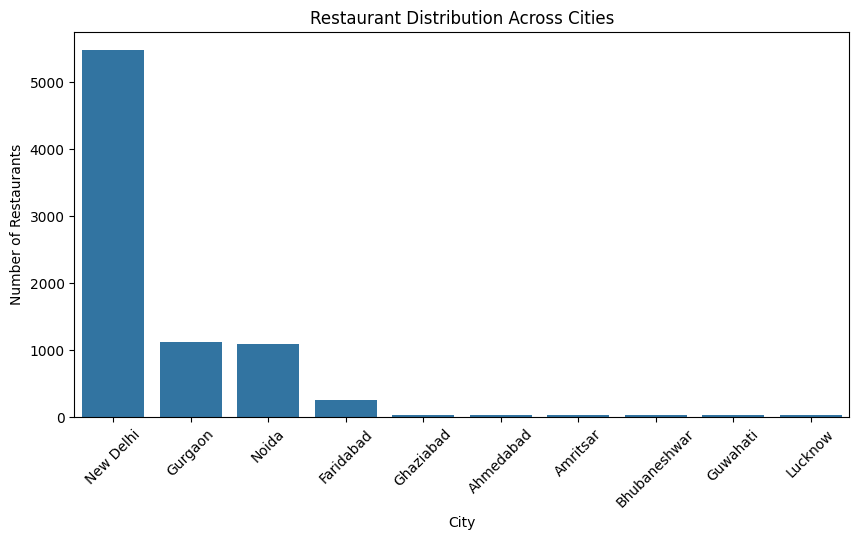

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=city_distribution.index,
    y=city_distribution.values
)

plt.title("Restaurant Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

In [8]:
correlation = df[['Latitude', 'Longitude', 'Aggregate rating']].corr()

print(correlation)

                  Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


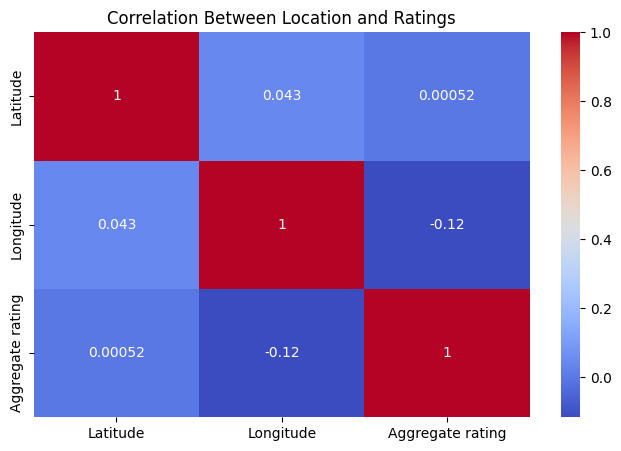

In [9]:
plt.figure(figsize=(8,5))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Between Location and Ratings")

plt.show()

## Conclusion

- Geospatial analysis was performed using latitude and longitude data.
- Restaurant locations were visualized on an interactive map.
- Some cities contain significantly more restaurants than others.
- Correlation analysis showed only a weak relationship between restaurant location and aggregate rating.
- Visualization techniques helped understand restaurant distribution patterns effectively.